# Sentiment Analysis of Singapore Airlines Passenger Reviews
## MSc Business Analytics — Machine Learning for Social Data Science
### Problem Set 2: Using Text as Data

**Research Question:** How accurately can NLP models classify passenger sentiment from Singapore Airlines reviews, and what thematic drivers underpin negative customer experiences?

**GitHub Repository:** [Insert link here]

---

## 1. Setup & Installation
Install all required packages and import libraries.

In [1]:
# ============================================================
# INSTALL REQUIRED PACKAGES
# Run this cell once to install dependencies
# ============================================================

!pip install pandas numpy matplotlib seaborn
!pip install nltk wordcloud
!pip install vaderSentiment
!pip install transformers torch
!pip install bertopic sentence-transformers
!pip install umap-learn hdbscan
!pip install scikit-learn
!pip install gensim  # For coherence score validation

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# --- Core Data Handling ---
import pandas as pd
import numpy as np

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- Text Preprocessing ---
import nltk
import re
from nltk.corpus import stopwords
from collections import Counter

# --- Sentiment Analysis Models ---
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # Lexicon-based
from transformers import pipeline  # RoBERTa (transfer learning)

# --- Topic Modelling ---
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

# --- Evaluation Metrics ---
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay,
                             precision_recall_fscore_support)

# --- Topic Coherence Validation ---
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# --- Download NLTK data ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# --- Plot styling ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# --- Create output directories ---
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print('All libraries imported successfully.')

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


## 2. Load & Inspect Data
Load the Singapore Airlines reviews dataset from Kaggle (Kanchana, 2024).
Source: https://www.kaggle.com/datasets/kanchana1990/singapore-airlines-reviews

In [3]:
# ============================================================
# LOAD DATASET
# Update the file path if your CSV is in a different location
# ============================================================

df = pd.read_csv('/Users/kritkhun/MSc/Machine Learning for DS/Assessment2/Dataset/singapore_airlines_reviews.csv')

# --- Basic inspection ---
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 3 rows:')
df.head(3)

Dataset shape: 10000 rows x 7 columns

Column names: ['published_date', 'published_platform', 'rating', 'type', 'text', 'title', 'helpful_votes']

Data types:
published_date        object
published_platform    object
rating                 int64
type                  object
text                  object
title                 object
helpful_votes          int64
dtype: object

First 3 rows:


,published_date,published_platform,rating,type,text,title,helpful_votes
0,2024-03-12T14:41:14-04:00,Desktop,3,review,We used this airline to go from Singapore to L...,Ok,0
1,2024-03-11T19:39:13-04:00,Desktop,5,review,The service on Singapore Airlines Suites Class...,The service in Suites Class makes one feel lik...,0
2,2024-03-11T12:20:23-04:00,Desktop,1,review,"Booked, paid and received email confirmation f...",Don’t give them your money,0


## 3. Descriptive Statistics
Comprehensive overview of the dataset to understand its structure, scope, and key features.

In [4]:
# ============================================================
# 3.1 MISSING VALUES CHECK
# ============================================================

print('=' * 50)
print('MISSING VALUES SUMMARY')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

# Drop rows with missing review text (essential for analysis)
df = df.dropna(subset=['text'])
print(f'\nRows after dropping missing text: {len(df)}')

MISSING VALUES SUMMARY
                    Missing Count  Percentage (%)
published_date                  0            0.00
published_platform              0            0.00
rating                          0            0.00
type                            0            0.00
text                            0            0.00
title                           1            0.01
helpful_votes                   0            0.00

Rows after dropping missing text: 10000


RATING DISTRIBUTION
Mean rating:   4.02
Median rating: 5.0
Std deviation: 1.35

Rating counts:
rating
1    1057
2     543
3    1009
4    1967
5    5424
Name: count, dtype: int64


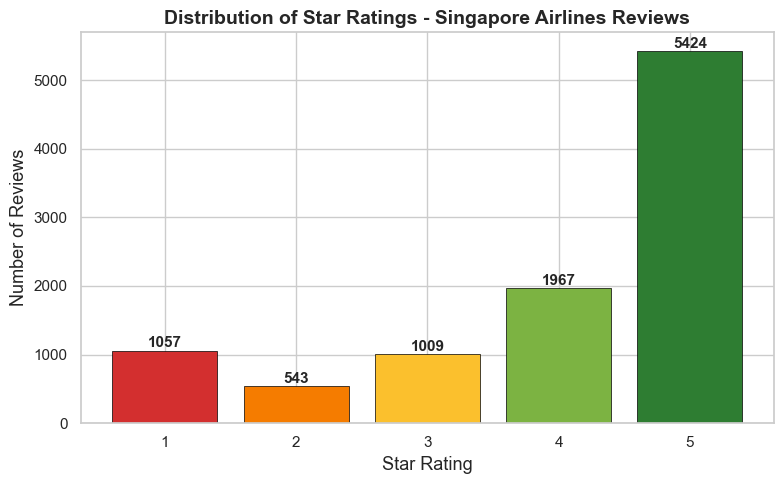

In [5]:
# ============================================================
# 3.2 RATING DISTRIBUTION
# Understanding the distribution of star ratings
# ============================================================

print('=' * 50)
print('RATING DISTRIBUTION')
print('=' * 50)
print(f'Mean rating:   {df["rating"].mean():.2f}')
print(f'Median rating: {df["rating"].median():.1f}')
print(f'Std deviation: {df["rating"].std():.2f}')
print(f'\nRating counts:\n{df["rating"].value_counts().sort_index()}')

# --- Plot: Rating distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
rating_counts = df['rating'].value_counts().sort_index()
unique_ratings = sorted(df['rating'].unique())
color_map = {1: '#d32f2f', 2: '#f57c00', 3: '#fbc02d', 4: '#7cb342', 5: '#2e7d32'}
bar_colors = [color_map.get(r, '#999999') for r in unique_ratings]

ax.bar([str(r) for r in unique_ratings],
       [rating_counts.get(r, 0) for r in unique_ratings],
       color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Star Rating', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.set_title('Distribution of Star Ratings - Singapore Airlines Reviews',
             fontsize=14, fontweight='bold')

for i, r in enumerate(unique_ratings):
    count = rating_counts.get(r, 0)
    ax.text(i, count + 50, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

REVIEW LENGTH STATISTICS (word count)
Mean:     99.0 words
Median:   67.0 words
Std Dev:  114.7 words
Min:      11 words
Max:      3213 words
25th pct: 39 words
75th pct: 119 words


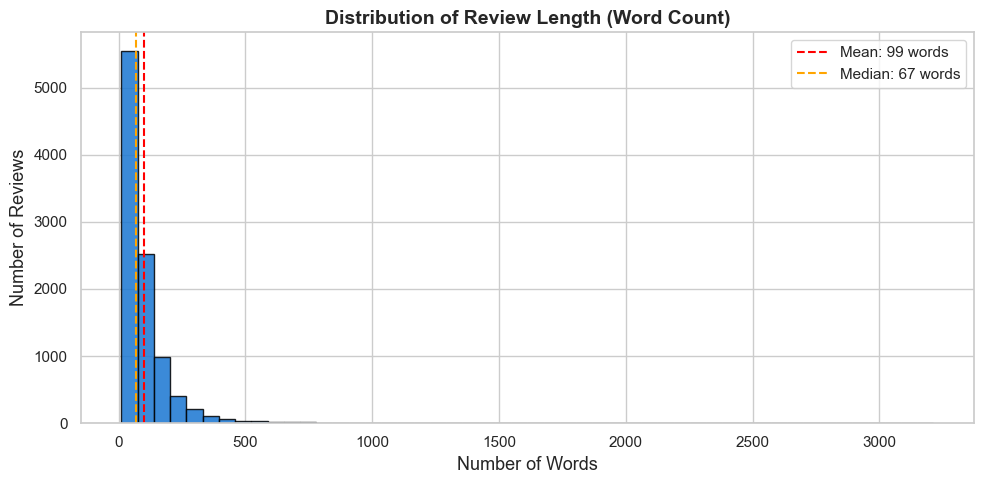

In [6]:
# ============================================================
# 3.3 REVIEW LENGTH ANALYSIS
# Important because RoBERTa has a 512-token limit and
# BERTopic performs differently on varying text lengths
# ============================================================

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print('=' * 50)
print('REVIEW LENGTH STATISTICS (word count)')
print('=' * 50)
print(f'Mean:     {df["word_count"].mean():.1f} words')
print(f'Median:   {df["word_count"].median():.1f} words')
print(f'Std Dev:  {df["word_count"].std():.1f} words')
print(f'Min:      {df["word_count"].min()} words')
print(f'Max:      {df["word_count"].max()} words')
print(f'25th pct: {df["word_count"].quantile(0.25):.0f} words')
print(f'75th pct: {df["word_count"].quantile(0.75):.0f} words')

# --- Plot: Review length histogram ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['word_count'], bins=50, color='#1976d2', edgecolor='black', alpha=0.85)
ax.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=1.5,
           label=f'Mean: {df["word_count"].mean():.0f} words')
ax.axvline(df['word_count'].median(), color='orange', linestyle='dashed', linewidth=1.5,
           label=f'Median: {df["word_count"].median():.0f} words')
ax.set_xlabel('Number of Words', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.set_title('Distribution of Review Length (Word Count)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# 3.4 PLATFORM DISTRIBUTION
# Which platforms are these reviews sourced from?
# ============================================================

print('=' * 50)
print('PLATFORM DISTRIBUTION')
print('=' * 50)
print(df['published_platform'].value_counts())
print(f'\nNumber of unique platforms: {df["published_platform"].nunique()}')

PLATFORM DISTRIBUTION
published_platform
Desktop    7352
Mobile     2648
Name: count, dtype: int64

Number of unique platforms: 2


Total words (after preprocessing): 500,604
Unique vocabulary size: 20,854


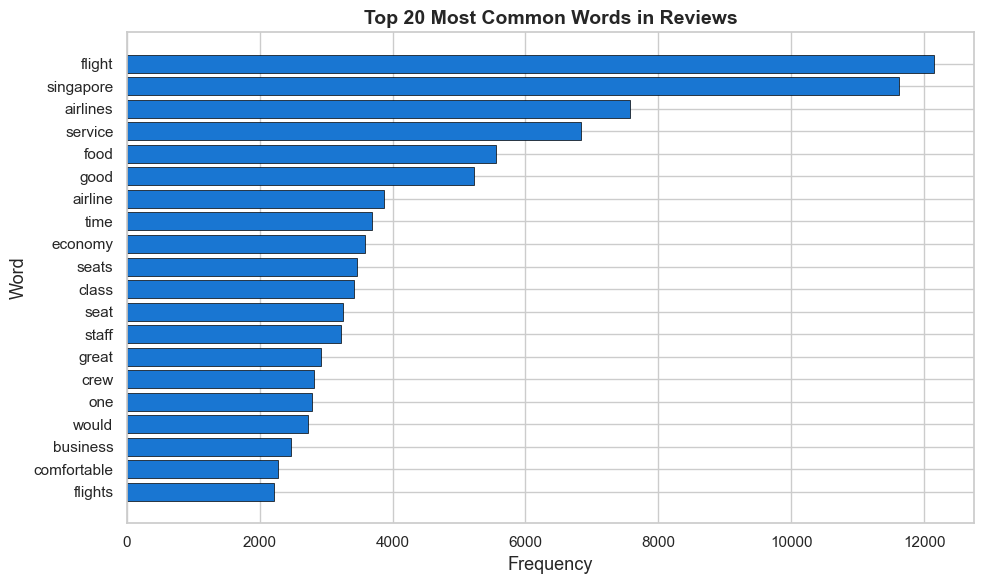

In [8]:
# ============================================================
# 3.5 MOST COMMON WORDS
# Visualise frequent words after removing stopwords
# ============================================================

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Lowercase, remove punctuation/numbers, remove stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

# Flatten all words
all_words = [word for review in df['text'].apply(preprocess_text) for word in review]

print(f'Total words (after preprocessing): {len(all_words):,}')
print(f'Unique vocabulary size: {len(set(all_words)):,}')

# Top 20 most common words
word_counts = Counter(all_words)
top_20 = word_counts.most_common(20)

words, counts = zip(*top_20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(reversed(words)), list(reversed(counts)),
        color='#1976d2', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Frequency', fontsize=13)
ax.set_ylabel('Word', fontsize=13)
ax.set_title('Top 20 Most Common Words in Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

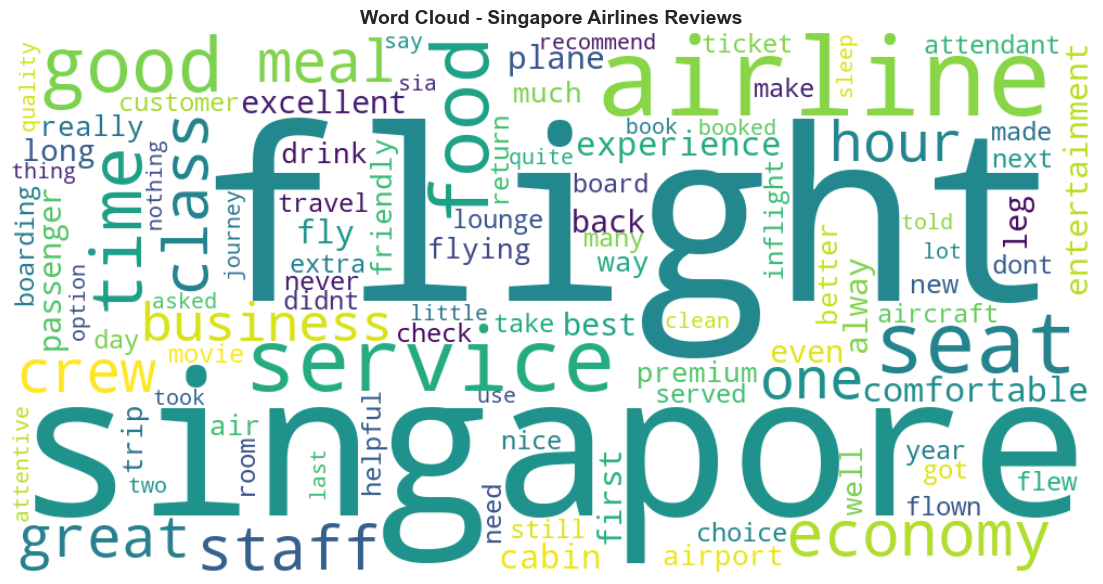

In [9]:
# ============================================================
# 3.6 WORD CLOUD
# Visual representation of most prominent words in the corpus
# ============================================================

wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      colormap='viridis', max_words=100,
                      collocations=False).generate(' '.join(all_words))

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud - Singapore Airlines Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sentiment Label Creation
Convert star ratings into three sentiment classes for model evaluation.
- **Negative**: Rating 1-2
- **Neutral**: Rating 3
- **Positive**: Rating 4-5

This creates our ground truth labels against which we compare VADER and RoBERTa predictions.

SENTIMENT CLASS DISTRIBUTION
  positive:  7391 reviews (73.9%)
   neutral:  1009 reviews (10.1%)
  negative:  1600 reviews (16.0%)


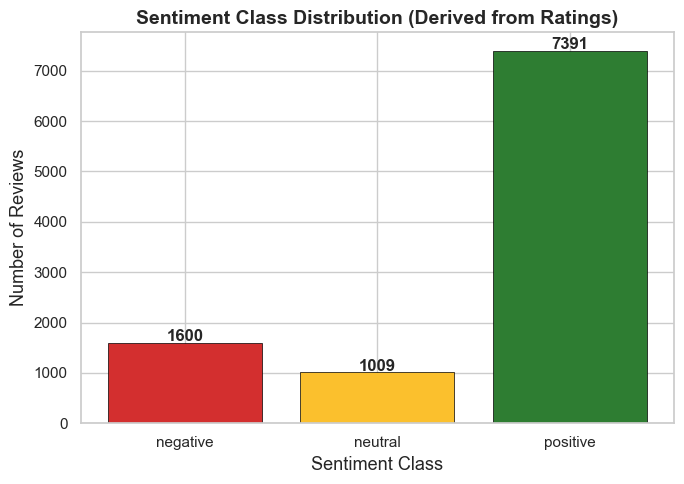

In [10]:
# ============================================================
# CREATE GROUND TRUTH SENTIMENT LABELS FROM STAR RATINGS
# Mapping: 1-2 stars -> negative, 3 stars -> neutral, 4-5 -> positive
# ============================================================

def rating_to_sentiment(rating):
    """Convert numerical star rating to sentiment category."""
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['true_sentiment'] = df['rating'].apply(rating_to_sentiment)

# --- Sentiment class distribution ---
print('=' * 50)
print('SENTIMENT CLASS DISTRIBUTION')
print('=' * 50)
sent_dist = df['true_sentiment'].value_counts()
sent_pct = (df['true_sentiment'].value_counts(normalize=True) * 100).round(1)
for label in ['positive', 'neutral', 'negative']:
    print(f'  {label:>8s}: {sent_dist.get(label, 0):>5d} reviews ({sent_pct.get(label, 0):.1f}%)')

# --- Plot: Sentiment distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
order = ['negative', 'neutral', 'positive']
colors_sent = {'negative': '#d32f2f', 'neutral': '#fbc02d', 'positive': '#2e7d32'}
counts = [sent_dist.get(s, 0) for s in order]
ax.bar(order, counts, color=[colors_sent[s] for s in order],
       edgecolor='black', linewidth=0.5)
for i, c in enumerate(counts):
    ax.text(i, c + 30, str(c), ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentiment Class', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.set_title('Sentiment Class Distribution (Derived from Ratings)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sentiment Classification - Model 1: VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment
analysis tool specifically attuned to social media text (Hutto & Gilbert, 2014). It uses a
pre-built dictionary of words scored for sentiment polarity and combines them with grammatical
rules (e.g., negation, capitalisation, punctuation) to produce a compound sentiment score.

**Why VADER as baseline?** It requires no training data, runs instantly, and is the standard
benchmark for sentiment analysis comparisons in NLP research.

In [11]:
# ============================================================
# VADER SENTIMENT ANALYSIS
# Uses compound score thresholds (Hutto & Gilbert, 2014):
#   compound >= 0.05  -> positive
#   compound <= -0.05 -> negative
#   otherwise         -> neutral
# ============================================================

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Classify text sentiment using VADER compound score."""
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER to all reviews
print('Running VADER sentiment analysis...')
df['vader_sentiment'] = df['text'].apply(get_vader_sentiment)
print(f'VADER predictions complete.\n{df["vader_sentiment"].value_counts()}')

# Also store the raw compound score for later analysis
df['vader_compound'] = df['text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound'])

Running VADER sentiment analysis...
VADER predictions complete.
vader_sentiment
positive    8148
negative    1745
neutral      107
Name: count, dtype: int64


VADER CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.61      0.67      0.64      1600
     neutral       0.27      0.03      0.05      1009
    positive       0.87      0.95      0.91      7391

    accuracy                           0.82     10000
   macro avg       0.58      0.55      0.53     10000
weighted avg       0.77      0.82      0.78     10000

Overall Accuracy: 0.8153 (81.5%)


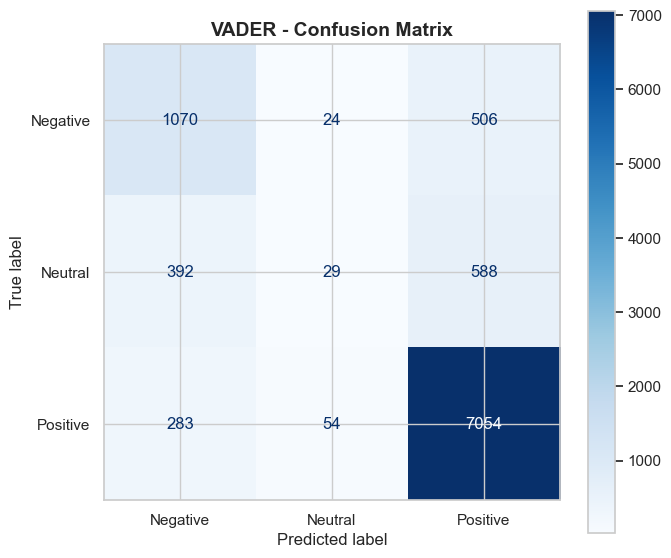

In [12]:
# ============================================================
# VADER EVALUATION
# Compare VADER predictions against ground truth labels
# ============================================================

print('=' * 60)
print('VADER CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(df['true_sentiment'], df['vader_sentiment'],
                            target_names=['negative', 'neutral', 'positive']))

vader_accuracy = accuracy_score(df['true_sentiment'], df['vader_sentiment'])
print(f'Overall Accuracy: {vader_accuracy:.4f} ({vader_accuracy*100:.1f}%)')

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(df['true_sentiment'], df['vader_sentiment'],
                      labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('VADER - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/vader_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sentiment Classification - Model 2: RoBERTa

RoBERTa (Robustly Optimised BERT Pretraining Approach) is a transformer-based model
pre-trained on large text corpora (Liu et al., 2019). We use the
`cardiffnlp/twitter-roberta-base-sentiment-latest` variant, fine-tuned on ~124M tweets
for sentiment classification (Barbieri et al., 2020).

**Why RoBERTa?** Unlike VADER, RoBERTa understands contextual meaning - it can interpret
negation ('not bad'), sarcasm, and complex sentence structures. This represents
state-of-the-art transfer learning applied to sentiment analysis.

In [13]:
# ============================================================
# ROBERTA SENTIMENT ANALYSIS
# Using Cardiff NLP pre-trained model (Barbieri et al., 2020)
# Note: RoBERTa has a 512-token limit, so we truncate longer reviews
# ============================================================

# Initialise the RoBERTa sentiment pipeline
roberta_pipeline = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    max_length=512,
    truncation=True
)

def get_roberta_sentiment(text):
    """Classify text sentiment using RoBERTa transformer model.
    Truncates input to 512 tokens (model limit).
    Returns: 'positive', 'negative', or 'neutral'
    """
    try:
        result = roberta_pipeline(str(text)[:512])[0]
        return result['label'].lower()
    except Exception as e:
        print(f'Error processing text: {e}')
        return 'neutral'  # Fallback for errors

# Apply RoBERTa - this takes several minutes on CPU
print('Running RoBERTa sentiment analysis (may take 10-20 min on CPU)...')

batch_size = 100
roberta_results = []
texts = df['text'].tolist()

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    batch_results = [get_roberta_sentiment(t) for t in batch]
    roberta_results.extend(batch_results)
    if (i // batch_size) % 10 == 0:
        print(f'  Processed {min(i+batch_size, len(texts)):,}/{len(texts):,} reviews...')

df['roberta_sentiment'] = roberta_results
print(f'\nRoBERTa predictions complete.\n{df["roberta_sentiment"].value_counts()}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 26257.67it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running RoBERTa sentiment analysis (may take 10-20 min on CPU)...
  Processed 100/10,000 reviews...
  Processed 1,100/10,000 reviews...
  Processed 2,100/10,000 reviews...
  Processed 3,100/10,000 reviews...
  Processed 4,100/10,000 reviews...
  Processed 5,100/10,000 reviews...
  Processed 6,100/10,000 reviews...
  Processed 7,100/10,000 reviews...
  Processed 8,100/10,000 reviews...
  Processed 9,100/10,000 reviews...

RoBERTa predictions complete.
roberta_sentiment
positive    6856
negative    2373
neutral      771
Name: count, dtype: int64


RoBERTa CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.56      0.83      0.67      1600
     neutral       0.18      0.13      0.15      1009
    positive       0.95      0.88      0.92      7391

    accuracy                           0.80     10000
   macro avg       0.56      0.62      0.58     10000
weighted avg       0.81      0.80      0.80     10000

Overall Accuracy: 0.7999 (80.0%)


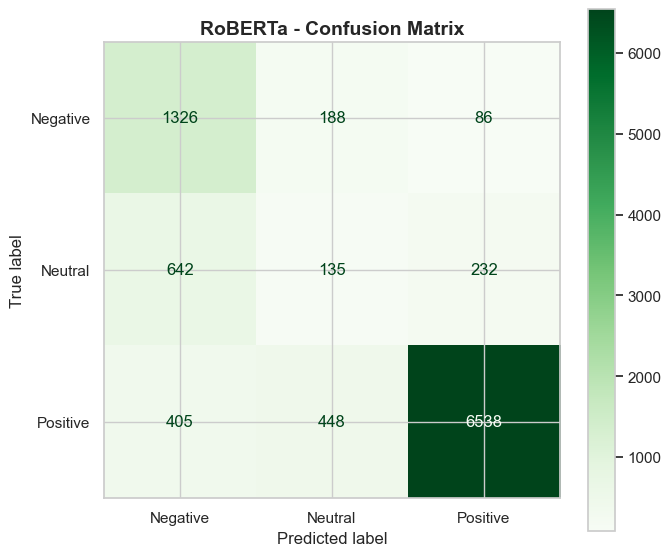

In [14]:
# ============================================================
# ROBERTA EVALUATION
# Compare RoBERTa predictions against ground truth labels
# ============================================================

print('=' * 60)
print('RoBERTa CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(df['true_sentiment'], df['roberta_sentiment'],
                            target_names=['negative', 'neutral', 'positive']))

roberta_accuracy = accuracy_score(df['true_sentiment'], df['roberta_sentiment'])
print(f'Overall Accuracy: {roberta_accuracy:.4f} ({roberta_accuracy*100:.1f}%)')

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
cm_rob = confusion_matrix(df['true_sentiment'], df['roberta_sentiment'],
                          labels=['negative', 'neutral', 'positive'])
disp_rob = ConfusionMatrixDisplay(confusion_matrix=cm_rob,
                                  display_labels=['Negative', 'Neutral', 'Positive'])
disp_rob.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('RoBERTa - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/roberta_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison: VADER vs RoBERTa
Side-by-side comparison to select the final model for sentiment classification.

MODEL COMPARISON SUMMARY
            Metric  VADER  RoBERTa
          Accuracy 0.8153   0.7999
Weighted Precision 0.7653   0.8119
   Weighted Recall 0.8153   0.7999
 Weighted F1-Score 0.7786   0.8005


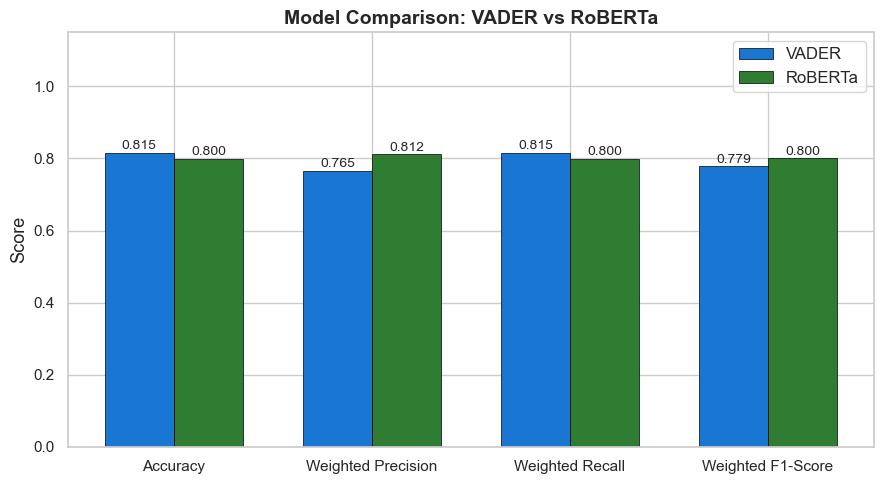


FINAL MODEL: RoBERTa (F1: 0.8005 vs VADER: 0.7786)
RoBERTa achieves higher weighted F1-score across all classes.


In [15]:
# ============================================================
# SIDE-BY-SIDE MODEL COMPARISON
# ============================================================

labels = ['negative', 'neutral', 'positive']

# VADER metrics
v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
    df['true_sentiment'], df['vader_sentiment'], labels=labels, average='weighted')

# RoBERTa metrics
r_prec, r_rec, r_f1, _ = precision_recall_fscore_support(
    df['true_sentiment'], df['roberta_sentiment'], labels=labels, average='weighted')

# --- Comparison table ---
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score'],
    'VADER': [vader_accuracy, v_prec, v_rec, v_f1],
    'RoBERTa': [roberta_accuracy, r_prec, r_rec, r_f1]
})
comparison[['VADER', 'RoBERTa']] = comparison[['VADER', 'RoBERTa']].round(4)

print('=' * 60)
print('MODEL COMPARISON SUMMARY')
print('=' * 60)
print(comparison.to_string(index=False))

# --- Bar chart comparison ---
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['VADER'], width, label='VADER',
               color='#1976d2', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, comparison['RoBERTa'], width, label='RoBERTa',
               color='#2e7d32', edgecolor='black', linewidth=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Comparison: VADER vs RoBERTa', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Final model selection ---
print('\n' + '=' * 60)
if r_f1 > v_f1:
    print(f'FINAL MODEL: RoBERTa (F1: {r_f1:.4f} vs VADER: {v_f1:.4f})')
    print('RoBERTa achieves higher weighted F1-score across all classes.')
else:
    print(f'FINAL MODEL: VADER (F1: {v_f1:.4f} vs RoBERTa: {r_f1:.4f})')
    print('VADER achieves comparable F1-score while being simpler and faster.')
print('=' * 60)

## 8. Topic Modelling with BERTopic

BERTopic (Grootendorst, 2022) is a neural topic modelling technique that leverages
transformer-based sentence embeddings, UMAP for dimensionality reduction, HDBSCAN
for clustering, and c-TF-IDF for topic representation.

**Why BERTopic over LDA?** BERTopic captures semantic meaning (contextual embeddings)
rather than relying solely on word co-occurrence frequencies, producing more coherent
and interpretable topics for domain-specific text like airline reviews.

In [16]:
# ============================================================
# 8.1 GENERATE EMBEDDINGS
# Using all-MiniLM-L6-v2 sentence transformer for efficiency
# ============================================================

print('Generating sentence embeddings (may take a few minutes)...')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(df['text'].tolist(), show_progress_bar=True)
print(f'Embeddings shape: {embeddings.shape}')

Generating sentence embeddings (may take a few minutes)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9070.96it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 313/313 [00:26<00:00, 12.01it/s]

Embeddings shape: (10000, 384)


In [17]:
# ============================================================
# 8.2 FIT BERTOPIC MODEL — ADJUSTED PARAMETERS
# 
# The initial run with min_cluster_size=50 produced only 2 topics
# due to the homogeneous vocabulary in single-airline reviews.
# We lower min_cluster_size to 15 and adjust UMAP to encourage
# finer-grained clustering.
# ============================================================

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# --- Attempt 1: min_cluster_size=30 ---
print("=" * 60)
print("ATTEMPT 1: min_cluster_size=30")
print("=" * 60)

umap_model_v1 = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model_v1 = HDBSCAN(
    min_cluster_size=30,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)
)

topic_model_v1 = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_v1,
    hdbscan_model=hdbscan_model_v1,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics_v1, probs_v1 = topic_model_v1.fit_transform(df['text'].tolist(), embeddings)
info_v1 = topic_model_v1.get_topic_info()
n_topics_v1 = len(info_v1) - 1  # exclude outlier -1
n_outliers_v1 = info_v1[info_v1['Topic'] == -1]['Count'].values[0]
print(f"Topics found: {n_topics_v1} | Outliers: {n_outliers_v1}")


# --- Attempt 2: min_cluster_size=20 ---
print("\n" + "=" * 60)
print("ATTEMPT 2: min_cluster_size=20")
print("=" * 60)

hdbscan_model_v2 = HDBSCAN(
    min_cluster_size=20,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

topic_model_v2 = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_v1,  # reuse same UMAP
    hdbscan_model=hdbscan_model_v2,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics_v2, probs_v2 = topic_model_v2.fit_transform(df['text'].tolist(), embeddings)
info_v2 = topic_model_v2.get_topic_info()
n_topics_v2 = len(info_v2) - 1
n_outliers_v2 = info_v2[info_v2['Topic'] == -1]['Count'].values[0]
print(f"Topics found: {n_topics_v2} | Outliers: {n_outliers_v2}")


# --- Attempt 3: min_cluster_size=15 ---
print("\n" + "=" * 60)
print("ATTEMPT 3: min_cluster_size=15")
print("=" * 60)

hdbscan_model_v3 = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

topic_model_v3 = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_v1,
    hdbscan_model=hdbscan_model_v3,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics_v3, probs_v3 = topic_model_v3.fit_transform(df['text'].tolist(), embeddings)
info_v3 = topic_model_v3.get_topic_info()
n_topics_v3 = len(info_v3) - 1
n_outliers_v3 = info_v3[info_v3['Topic'] == -1]['Count'].values[0]
print(f"Topics found: {n_topics_v3} | Outliers: {n_outliers_v3}")


# --- Summary of all attempts ---
print("\n" + "=" * 60)
print("PARAMETER TUNING SUMMARY")
print("=" * 60)
print(f"{'min_cluster_size':<20s} {'Topics':<10s} {'Outliers':<10s}")
print("-" * 40)
print(f"{'50 (initial)':<20s} {2:<10d} {24:<10d}")
print(f"{'30':<20s} {n_topics_v1:<10d} {n_outliers_v1:<10d}")
print(f"{'20':<20s} {n_topics_v2:<10d} {n_outliers_v2:<10d}")
print(f"{'15':<20s} {n_topics_v3:<10d} {n_outliers_v3:<10d}")

# --- Select the best model ---
# Pick the one with the most interpretable number of topics (ideally 5-25)
best_models = {30: (topic_model_v1, n_topics_v1), 
               20: (topic_model_v2, n_topics_v2), 
               15: (topic_model_v3, n_topics_v3)}

# Choose the model with the most topics (but if >30, we'll reduce later)
best_size = max(best_models, key=lambda k: best_models[k][1])
topic_model = best_models[best_size][0]
n_final = best_models[best_size][1]
print(f"\nSelected: min_cluster_size={best_size} with {n_final} topics")


2026-03-26 01:08:19,867 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


ATTEMPT 1: min_cluster_size=30


2026-03-26 01:08:34,756 - BERTopic - Dimensionality - Completed ✓
2026-03-26 01:08:34,757 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-26 01:08:34,975 - BERTopic - Cluster - Completed ✓
2026-03-26 01:08:34,976 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-26 01:08:35,355 - BERTopic - Representation - Completed ✓
2026-03-26 01:08:35,382 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Topics found: 2 | Outliers: 24

ATTEMPT 2: min_cluster_size=20


2026-03-26 01:08:44,098 - BERTopic - Dimensionality - Completed ✓
2026-03-26 01:08:44,098 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-26 01:08:44,286 - BERTopic - Cluster - Completed ✓
2026-03-26 01:08:44,288 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-26 01:08:44,672 - BERTopic - Representation - Completed ✓
2026-03-26 01:08:44,698 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Topics found: 2 | Outliers: 2

ATTEMPT 3: min_cluster_size=15


2026-03-26 01:08:53,435 - BERTopic - Dimensionality - Completed ✓
2026-03-26 01:08:53,436 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-26 01:08:53,611 - BERTopic - Cluster - Completed ✓
2026-03-26 01:08:53,613 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-26 01:08:54,086 - BERTopic - Representation - Completed ✓


Topics found: 43 | Outliers: 3724

PARAMETER TUNING SUMMARY
min_cluster_size     Topics     Outliers  
----------------------------------------
50 (initial)         2          24        
30                   2          24        
20                   2          2         
15                   43         3724      

Selected: min_cluster_size=15 with 43 topics


In [18]:
# ============================================================
# 8.3 TOPIC REDUCTION (IF NEEDED)
# If too many topics, reduce for interpretability
# ============================================================

df['topic'] = topic_model.topics_
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info) - 1

print(f"Current topics: {n_topics}")

# If too many topics (>25), reduce for interpretability
if n_topics > 25:
    print(f"Reducing from {n_topics} to 20...")
    topic_model = topic_model.reduce_topics(df['text'].tolist(), nr_topics=20)
    df['topic'] = topic_model.topics_
    topic_info = topic_model.get_topic_info()
    print(f"After reduction: {len(topic_info) - 1} topics")

# Display final topic table
print('\n' + '=' * 80)
print('FINAL TOPICS')
print('=' * 80)
for _, row in topic_info.iterrows():
    keywords = ', '.join(row['Representation'][:8])
    print(f'Topic {row["Topic"]:>3d} | Count: {row["Count"]:>5d} | Keywords: {keywords}')

2026-03-26 01:08:54,289 - BERTopic - Topic reduction - Reducing number of topics
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
2026-03-26 01:08:54,297 - BERTopic - Representation - Fine-tuning topics using representation models.


Current topics: 43
Reducing from 43 to 20...


2026-03-26 01:08:54,764 - BERTopic - Representation - Completed ✓
2026-03-26 01:08:54,765 - BERTopic - Topic reduction - Reduced number of topics from 44 to 20


After reduction: 19 topics

FINAL TOPICS
Topic  -1 | Count:  3724 | Keywords: singapore, flight, airlines, singapore airlines, service, food, good, class
Topic   0 | Count:  2262 | Keywords: good, flight, food, service, great, staff, crew, comfortable
Topic   1 | Count:  1423 | Keywords: singapore, airlines, singapore airlines, flight, service, good, food, airline
Topic   2 | Count:   571 | Keywords: flight, singapore, refund, airlines, singapore airlines, customer, ticket, booking
Topic   3 | Count:   375 | Keywords: singapore, flight, meal, food, airlines, singapore airlines, meals, service
Topic   4 | Count:   334 | Keywords: sq, service, flight, crew, class, good, food, experience
Topic   5 | Count:   299 | Keywords: economy, premium, premium economy, seats, extra, singapore, food, seat
Topic   6 | Count:   234 | Keywords: a380, flight, seats, service, good, seat, comfortable, great
Topic   7 | Count:   223 | Keywords: seat, singapore, seats, flight, airlines, singapore airlines, w

In [19]:
# ============================================================
# 8.4 TOPIC VALIDATION
# Coherence score (Cv) and topic diversity
# ============================================================

# --- Coherence Score ---
docs_cleaned = [preprocess_text(doc) for doc in df['text'].tolist()]
dictionary = Dictionary(docs_cleaned)

topics_dict = topic_model.get_topics()
topic_words = [
    [word for word, _ in topics_dict[tid][:10]]
    for tid in topics_dict.keys()
    if tid != -1
]

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=docs_cleaned,
    dictionary=dictionary,
    coherence='c_v',
    window_size=50
)
coherence_score = coherence_model.get_coherence()
print(f'\nTopic Coherence Score (Cv): {coherence_score:.4f}')

all_topic_words = [w for words in topic_words for w in words]
unique_words = set(all_topic_words)
diversity_score = len(unique_words) / len(all_topic_words)
print(f'Topic Diversity Score: {diversity_score:.4f}')


Topic Coherence Score (Cv): 0.4829
Topic Diversity Score: 0.4895


In [20]:
# ============================================================
# 8.5 BERTOPIC VISUALISATIONS
# Note: visualize_topics() can fail with few topics due to
# internal UMAP reduction. We wrap in try/except.
# ============================================================

# --- Intertopic Distance Map ---
try:
    fig_topics = topic_model.visualize_topics()
    fig_topics.write_html('figures/intertopic_distance.html')
    fig_topics.show()
    print("Saved: figures/intertopic_distance.html")
except Exception as e:
    print(f"visualize_topics() failed: {e}")
    print("Skipping — known UMAP issue with small topic counts.")

# --- Topic Bar Chart (Top 10) ---
fig_bars = topic_model.visualize_barchart(top_n_topics=min(10, n_topics))
fig_bars.write_html('figures/topic_barchart.html')
fig_bars.show()
print("Saved: figures/topic_barchart.html")

# --- Hierarchical Clustering ---
try:
    fig_hier = topic_model.visualize_hierarchy()
    fig_hier.write_html('figures/topic_hierarchy.html')
    fig_hier.show()
    print("Saved: figures/topic_hierarchy.html")
except Exception as e:
    print(f"visualize_hierarchy() failed: {e}")

# --- Similarity Heatmap ---
try:
    fig_heat = topic_model.visualize_heatmap()
    fig_heat.write_html('figures/topic_heatmap.html')
    fig_heat.show()
    print("Saved: figures/topic_heatmap.html")
except Exception as e:
    print(f"visualize_heatmap() failed: {e}")

Saved: figures/intertopic_distance.html


Saved: figures/topic_barchart.html


Saved: figures/topic_hierarchy.html


Saved: figures/topic_heatmap.html


## 9. Cross-Analysis: Topics x Sentiment
This is the key business insight - mapping which themes are associated with
negative vs positive sentiment to provide actionable recommendations.

Using ROBERTA predictions for cross-analysis



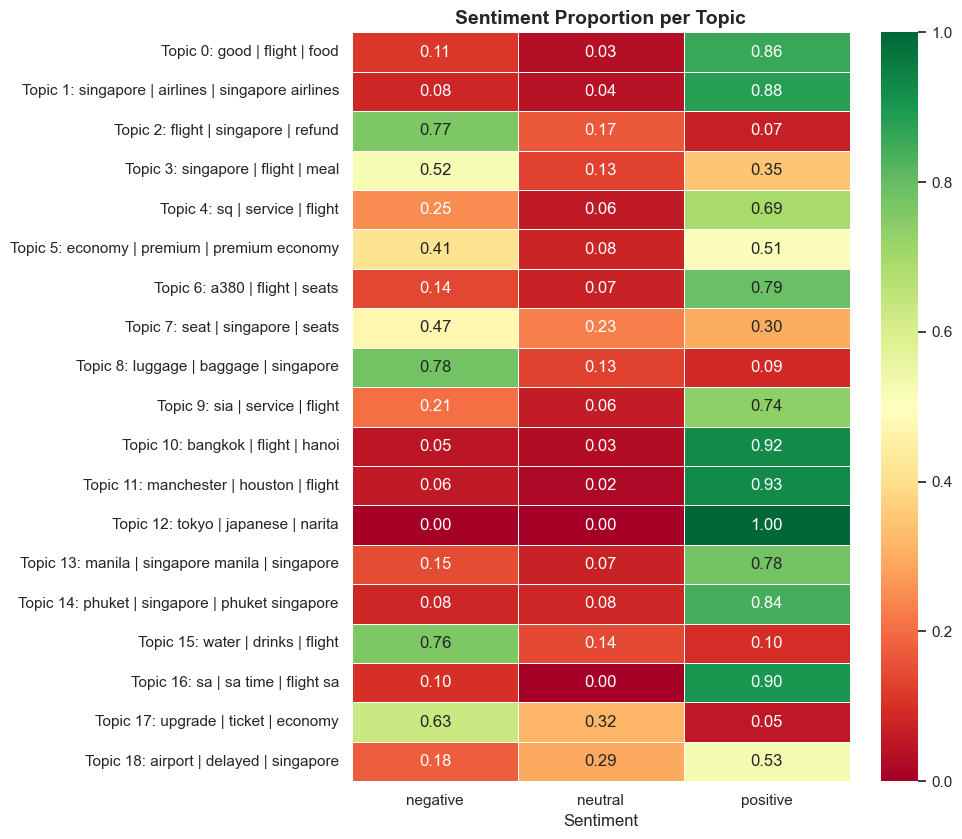

In [21]:
# ============================================================
# 9.1 SENTIMENT DISTRIBUTION PER TOPIC
# For each BERTopic theme, calculate the proportion of
# negative, neutral, and positive reviews
# ============================================================

# Use the best-performing sentiment model
best_col = 'roberta_sentiment' if r_f1 > v_f1 else 'vader_sentiment'
print(f'Using {best_col.split("_")[0].upper()} predictions for cross-analysis\n')


# Sentiment proportions per topic (exclude outlier -1)
topic_sentiment = (df[df['topic'] != -1]
    .groupby('topic')[best_col]
    .value_counts(normalize=True)
    .unstack(fill_value=0))

for col in ['negative', 'neutral', 'positive']:
    if col not in topic_sentiment.columns:
        topic_sentiment[col] = 0
topic_sentiment = topic_sentiment[['negative', 'neutral', 'positive']]

# Add topic keywords as labels
topic_labels = {}
for tid in topic_sentiment.index:
    words = [w for w, _ in topic_model.get_topic(tid)[:3]]
    topic_labels[tid] = f'Topic {tid}: {" | ".join(words)}'
topic_sentiment.index = [topic_labels.get(t, f'Topic {t}') for t in topic_sentiment.index]

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(10, max(6, len(topic_sentiment) * 0.45)))
sns.heatmap(topic_sentiment, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Sentiment Proportion per Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('', fontsize=12)
plt.tight_layout()
plt.savefig('figures/topic_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ============================================================
# 9.2 MOST NEGATIVE AND MOST POSITIVE TOPICS
# Identify which themes Singapore Airlines should prioritise
# ============================================================

topic_sent_raw = (df[df['topic'] != -1]
    .groupby('topic')[best_col]
    .value_counts(normalize=True)
    .unstack(fill_value=0))
for col in ['negative', 'neutral', 'positive']:
    if col not in topic_sent_raw.columns:
        topic_sent_raw[col] = 0

topic_counts = df[df['topic'] != -1].groupby('topic').size()

print('=' * 70)
print('TOP 5 MOST NEGATIVE TOPICS')
print('=' * 70)
most_negative = topic_sent_raw.sort_values('negative', ascending=False).head(5)
for tid in most_negative.index:
    keywords = ', '.join([w for w, _ in topic_model.get_topic(tid)[:5]])
    neg_pct = most_negative.loc[tid, 'negative'] * 100
    count = topic_counts.get(tid, 0)
    print(f'  Topic {tid:>2d} | {neg_pct:>5.1f}% negative | {count:>4d} reviews | {keywords}')

print()
print('=' * 70)
print('TOP 5 MOST POSITIVE TOPICS')
print('=' * 70)
most_positive = topic_sent_raw.sort_values('positive', ascending=False).head(5)
for tid in most_positive.index:
    keywords = ', '.join([w for w, _ in topic_model.get_topic(tid)[:5]])
    pos_pct = most_positive.loc[tid, 'positive'] * 100
    count = topic_counts.get(tid, 0)
    print(f'  Topic {tid:>2d} | {pos_pct:>5.1f}% positive | {count:>4d} reviews | {keywords}')


TOP 5 MOST NEGATIVE TOPICS
  Topic  8 |  77.9% negative |  136 reviews | luggage, baggage, singapore, lost, bag
  Topic  2 |  76.5% negative |  571 reviews | flight, singapore, refund, airlines, singapore airlines
  Topic 15 |  76.2% negative |   21 reviews | water, drinks, flight, attendant, food
  Topic 17 |  63.2% negative |   19 reviews | upgrade, ticket, economy, class, premium
  Topic  3 |  52.3% negative |  375 reviews | singapore, flight, meal, food, airlines

TOP 5 MOST POSITIVE TOPICS
  Topic 12 | 100.0% positive |   34 reviews | tokyo, japanese, narita, flight, japan
  Topic 11 |  92.6% positive |   54 reviews | manchester, houston, flight, flight manchester, singapore
  Topic 10 |  92.4% positive |   66 reviews | bangkok, flight, hanoi, singapore, airlines
  Topic 16 |  90.0% positive |   20 reviews | sa, sa time, flight sa, food, great
  Topic  1 |  88.1% positive | 1423 reviews | singapore, airlines, singapore airlines, flight, service


## 10. Summary of Key Findings
Consolidated results for inclusion in the written report.

In [23]:
# ============================================================
# FINAL SUMMARY
# ============================================================

df.to_csv('results/processed_reviews_with_sentiment_fixing_BERTopic.csv', index=False)
print(f'\nUpdated data saved.')

print('\n' + '=' * 60)
print('ANALYSIS SUMMARY')
print('=' * 60)
print(f'Dataset: {len(df):,} Singapore Airlines reviews')
print(f'VADER Accuracy:   {vader_accuracy:.4f} (F1: {v_f1:.4f})')
print(f'RoBERTa Accuracy: {roberta_accuracy:.4f} (F1: {r_f1:.4f})')
winner = 'RoBERTa' if r_f1 > v_f1 else 'VADER'
print(f'Best model: {winner}')
print(f'BERTopic: {len(topic_info)-1} topics discovered')
print(f'Coherence Score (Cv): {coherence_score:.4f}')
print(f'Topic Diversity: {diversity_score:.4f}')



Updated data saved.

ANALYSIS SUMMARY
Dataset: 10,000 Singapore Airlines reviews
VADER Accuracy:   0.8153 (F1: 0.7786)
RoBERTa Accuracy: 0.7999 (F1: 0.8005)
Best model: RoBERTa
BERTopic: 19 topics discovered
Coherence Score (Cv): 0.4829
Topic Diversity: 0.4895
